# Working with Hydro-PE data
## NetCDF version using R

<img width="309" height="57" alt="UKCEH and FDRI logos" src="https://github.com/user-attachments/assets/04afdc63-663f-41e4-b29d-9419f78d76c3" />
</br>

**Authors:** [Matt Dalle Piagge](https://mattjbr123.github.io/) and Kit Macleod. With help from: Matt Fry, Mike Brown, Anna Rose Klaptocz, Faiza Samreen, Matt Coole

---

**Launch this notebook:**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NERC-CEH/fdri-gridded-notebooks/blob/main/notebooks/Hydro-PE/hydrope_netcdf_R.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/NERC-CEH/fdri-gridded-notebooks/HEAD?labpath=notebooks/Hydro-PE/hydrope_netcdf_R.ipynb)

(Ctrl + Click to open in a new tab)

> **Google Colab:** If running in Google Colab, you will need to switch to an R runtime. Click the "Runtime" menu in the menu bar at the top of the screen, select Change runtime type, select R from the 'Runtime type' drop down box, you can leave the rest the same.

Full instructions available in the [accompanying README](https://github.com/NERC-CEH/fdri-gridded-notebooks/blob/main/README.md#R).


---

## What this notebook does

This notebook explores the **Hydro-PE** dataset. [Hydro-PE](https://doi.org/10.5285/2aa2c8ab-9e32-4b3b-9636-503912305aca) is an observations-derived gridded Potential Evaporation dataset for the UK produced by [UKCEH](https://www.ceh.ac.uk/) using the [HadUK-Grid](https://dx.doi.org/10.5285/f02cc6ddd92f45b18b9ab6ab544df7d9) dataset. It contains two variables, Potential Evapotranspiration (PE or PET) and Potential Evapotranspiration with Interception correction (PETI). See the supporting documentation on the [catalogue page](https://doi.org/10.5285/2aa2c8ab-9e32-4b3b-9636-503912305aca) for more information on how these are calculated.

Simple examples are shown for exploring and working with the dataset, which can be generalised to any gridded dataset stored in NetCDF format.

A key limitation of working with NetCDF is that data files have to be downloaded to your machine - or wherever you are running the notebook - before you can work with them. This is why we also provide a [version](https://colab.research.google.com/github/NERC-CEH/fdri-gridded-notebooks/blob/main/notebooks/Hydro-PE/hydrope_zarr_R.ipynb) of this notebook that uses the Zarr format instead, which removes the limitation and allows you to work with multi-terabyte datasets without worrying about having to download it all.

**We will:**
1. Show how to open a dataset stored in NetCDF format
2. Show how to extract and plot a time series at a single location, and demonstrate the limitations of NetCDF for this
3. Show how to plot a map at a single time step


**Data store:**
The data is currently publicly available via the EIDC: https://doi.org/10.5285/2aa2c8ab-9e32-4b3b-9636-503912305aca

---

## 0. Setup

Install and load `ncdf4`. This may take a couple minutes.

In [ ]:
if (!requireNamespace("ncdf4", quietly = TRUE))
  install.packages("ncdf4", repos = "https://cloud.r-project.org", verbose = TRUE)

library(ncdf4)
cat("ncdf4 version:", as.character(packageVersion("ncdf4")), "\n")

---
## 1. Download the NetCDF file

To work with NetCDF data we have to download the files ourselves, to our local machines (desktops/laptops), or wherever this notebook is running. A dataset in NetCDF format is usually split up into several files, typically across the time dimension.

To see what files are available, go to the [catalogue web-page](https://doi.org/10.5285/2aa2c8ab-9e32-4b3b-9636-503912305aca) for this dataset and click 'Download', then the Download button next to the 'Direct Access Files' option that appears from the left.

Looking at the filenames tells you that the dataset is split into monthly files across the time span it covers. Looking at the sizes in the 3rd column tells you that each file is around 40MB. You can also see that there are a lot of files. Each file contains a month's worth of daily PET or PETI values across the UK.

We will therefore download only a single file of the data, obtaining the URL by right clicking on the file of interest (in this case for Jan 2000's PET) and selecting 'Copy Link'. This link is used below to download the file:

In [2]:
nc_url  <- paste0(
  "https://catalogue.ceh.ac.uk/datastore/eidchub/2aa2c8ab-9e32-4b3b-9636-503912305aca/hydro-pe_hadukgrid_pet_1km_day_20000101-20000131.nc"
)
nc_filename <- "hydro-pe_hadukgrid_pet_1km_day_20000101-20000131.nc"

if (!file.exists(nc_filename)) {
  cat("Downloading file (~40 MB)...\n")
  download.file(nc_url, nc_filename, mode = "wb", quiet = FALSE)
} else {
  cat("File already downloaded.\n")
}

cat(sprintf("File size: %.1f MB\n", file.size(nc_filename) / 1e6))

File size: 40.9 MB


---
## 2. Open the file and inspect metadata

In [3]:
nc <- nc_open(nc_filename)

# Print the full file summary — similar to ncdump -h
cat("=== FILE SUMMARY ===\n")
cat("Format   :", nc$format, "\n")
cat("Variables:", nc$nvars, "\n")
cat("Dims     :", nc$ndims, "\n")

=== FILE SUMMARY ===
Format   : NC_FORMAT_NETCDF4 
Variables: 7 
Dims     : 4 


### 2a. Global attributes (dataset-wide metadata)

In [4]:
cat("=== GLOBAL ATTRIBUTES ===\n")
gatts <- ncatt_get(nc, 0)
for (nm in names(gatts)) {
  val <- as.character(gatts[[nm]])
  cat(sprintf("  %-30s : %s\n", nm, val))
}

=== GLOBAL ATTRIBUTES ===
  title                          : Potential evapotranspiration derived from the HadUK-Grid 1km gridded climate observations (Hydro-PE HadUK-Grid)
  summary                        : Gridded potential evapotranspiration calculated from HadUK-Grid gridded observed meteorological data at 1 km resolution over the United Kingdom for the years 1969 onwards. This dataset contains two potential evapotranspiration variables: daily total potential evapotranspiration (PET; kg m-2 d-1) and daily total potential evapotranspiration with interception correction (PETI; kg m-2 d-1). The units kg m-2 d-1 are equivalent to mm d-1. The data are provided in gridded netCDF files. There is one file for each variable, for each calendar month.
  source                         : This dataset was derived from the HadUK-Grid gridded observed meteorological dataset v1.0.3.0 at 1 km resolution over the United Kingdom for the years 1969-2020 inclusive, v1.1.0.0 for 2021 and v1.2.0.0 for 202

### 2b. Variables

In [5]:
cat("=== VARIABLES ===\n")
for (v in nc$var) {
  dim_str <- paste(sapply(v$dim, function(d) d$name), collapse = " × ")
  units   <- ncatt_get(nc, v$name, "units")$value
  lname   <- ncatt_get(nc, v$name, "long_name")$value
  cat(sprintf("  %-30s [%s]\n", v$name, dim_str))
  if (!is.logical(units)) cat(sprintf("    units     : %s\n", units))
  if (!is.logical(lname)) cat(sprintf("    long_name : %s\n", lname))
}

=== VARIABLES ===
  lat                            [x × y]
    units     : degrees_north
    long_name : latitude
  lon                            [x × y]
    units     : degrees_east
    long_name : longitude
  time_bnds                      [bnds × time]
    units     : 0
    long_name : 0
  x_bnds                         [bnds × x]
    units     : 0
    long_name : 0
  y_bnds                         [bnds × y]
    units     : 0
    long_name : 0
  crsOSGB                        []
    units     : 0
    long_name : 0
  pet                            [x × y × time]
    units     : kg m-2 d-1
    long_name : Potential evapotranspiration


### 2c. Dimensions

In [6]:
cat("=== DIMENSIONS ===\n")
for (dim in nc$dim) {
  cat(sprintf("  %-10s : %d values\n", dim$name, dim$len))
}

=== DIMENSIONS ===
  x          : 900 values
  y          : 1450 values
  time       : 31 values
  bnds       : 2 values


### 2d Read coordinate arrays

In [7]:
x    <- ncvar_get(nc, "x")     # easting, metres
y    <- ncvar_get(nc, "y")     # northing, metres
time <- ncvar_get(nc, "time")  # time values

# Decode time axis
time_units <- ncatt_get(nc, "time", "units")$value

# Parse "hours since YYYY-MM-DD" format
origin_str <- sub(".*since\\s+", "", time_units)
origin_dt  <- as.POSIXct(origin_str, tz = "UTC",
                format = ifelse(grepl(":", origin_str), "%Y-%m-%d %H:%M:%S", "%Y-%m-%d"))

# Determine units multiplier (hours → seconds; days → seconds; etc.)
unit_word  <- tolower(sub("\\s+since.*", "", time_units))
multiplier <- switch(unit_word,
  "hours"   = 3600,
  "days"    = 86400,
  "minutes" = 60,
  "seconds" = 1,
  3600  # default to hours
)

datetimes <- origin_dt + as.numeric(time) * multiplier

cat(sprintf("x (easting) : %d values, %.0f m to %.0f m  (%.0f m spacing)\n",
  length(x), min(x), max(x), x[2] - x[1]))
cat(sprintf("y (northing): %d values, %.0f m to %.0f m  (%.0f m spacing)\n",
  length(y), min(y), max(y), y[1] - y[2]))
cat(sprintf("Time        : %d steps, %s to %s\n",
  length(datetimes), min(datetimes), max(datetimes)))

x (easting) : 900 values, -199500 m to 699500 m  (1000 m spacing)
y (northing): 1450 values, -199500 m to 1249500 m  (-1000 m spacing)
Time        : 31 steps, 2000-01-01 12:00:00 to 2000-01-31 12:00:00


---
## 3. Time series at a single location

We find the nearest grid cell to a target x/y coordinate, then read all the timesteps for this file.

**Key Point:** To plot different months we would have to download the relevant files of the dataset as we did in Section 1. If we wanted to plot multiple months we would have to download multiple large files, if not the whole dataset, which quickly gets unwieldy given the size of the dataset. For increased flexibility and ease-of-use, consider using the Zarr version of the dataset instead via [this notebook](https://colab.research.google.com/github/NERC-CEH/fdri-gridded-notebooks/blob/main/notebooks/Hydro-PE/hydrope_zarr_R.ipynb).

Load the data:

In [8]:
# Target location in British National Grid coordinates (easting, northing in metres)
# Edinburgh ~ (325000, 673000)
target_x <- 325000
target_y <- 673000

# Find the nearest grid cell indices
i_x <- which.min(abs(x - target_x))
i_y <- which.min(abs(y - target_y))

cat(sprintf("Target  : x=%d, y=%d\n", target_x, target_y))
cat(sprintf("Nearest : x=%.0f (index %d), y=%.0f (index %d)\n",
  x[i_x], i_x, y[i_y], i_y))

# Read all time steps for this single grid cell
# start = [x_index, y_index, time_index_1], count = [1, 1, all_times]
ts_vals <- ncvar_get(
  nc, "pet",
  start = c(i_x, i_y, 1),
  count = c(1, 1, length(time))
)

ts_df <- data.frame(date = datetimes, rainfall_mm = as.numeric(ts_vals))
print(ts_df)

Target  : x=325000, y=673000
Nearest : x=324500 (index 525), y=672500 (index 873)
                  date rainfall_mm
1  2000-01-01 12:00:00  1.22759390
2  2000-01-02 12:00:00  1.47794986
3  2000-01-03 12:00:00  0.75188333
4  2000-01-04 12:00:00  0.60355872
5  2000-01-05 12:00:00  1.36465836
6  2000-01-06 12:00:00  0.93156761
7  2000-01-07 12:00:00  1.14992094
8  2000-01-08 12:00:00  0.39475474
9  2000-01-09 12:00:00  0.51857269
10 2000-01-10 12:00:00  1.14923978
11 2000-01-11 12:00:00  1.02735651
12 2000-01-12 12:00:00  0.21717586
13 2000-01-13 12:00:00  0.16498916
14 2000-01-14 12:00:00  0.00000000
15 2000-01-15 12:00:00  0.10141917
16 2000-01-16 12:00:00  0.54215473
17 2000-01-17 12:00:00  0.75666589
18 2000-01-18 12:00:00  0.58269554
19 2000-01-19 12:00:00  0.48285145
20 2000-01-20 12:00:00  0.40541771
21 2000-01-21 12:00:00  0.50667787
22 2000-01-22 12:00:00  0.13382313
23 2000-01-23 12:00:00  0.31620294
24 2000-01-24 12:00:00  0.13375686
25 2000-01-25 12:00:00  0.06011935
26 2000-

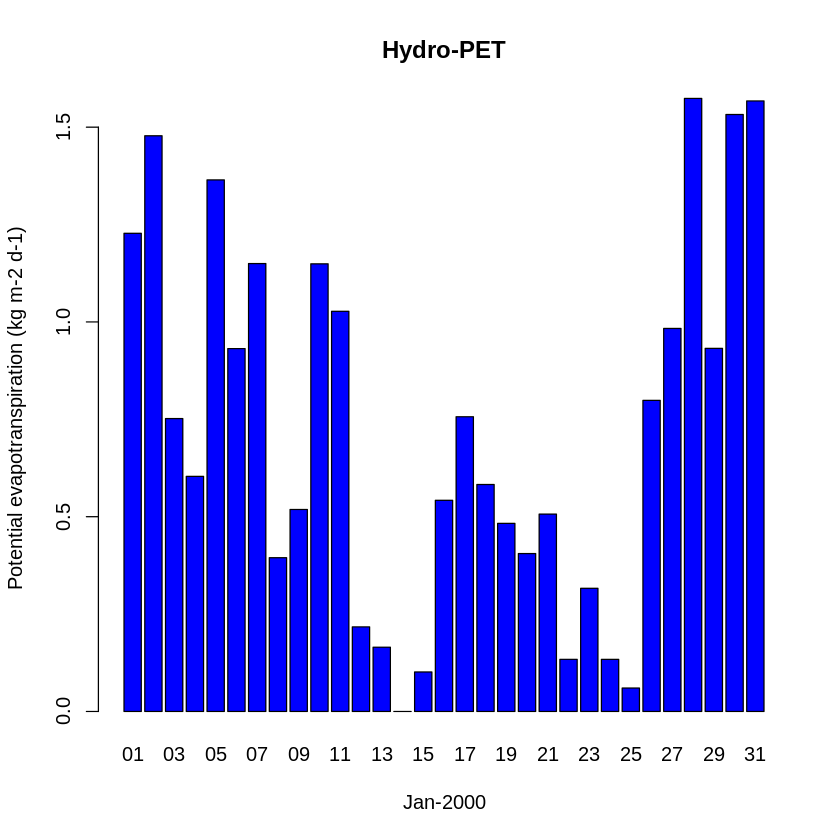

In [9]:
units    <- ncatt_get(nc, "pet", "units")$value
longname <- ncatt_get(nc, "pet", "long_name")$value

barplot(
  ts_df$rainfall_mm,
  names.arg = format(ts_df$date, "%d"),
  col  = "blue",
  main = paste("Hydro-PET"),
  xlab = format(datetimes[1], "%b-%Y"),
  ylab = paste0(longname, " (", units, ")"),
)

---
## 5. Map at a single time step

Read the full 2-D spatial grid for the first time step (Jan 1st 2000) and plot it.

In [10]:
# Read spatial slice for the first time step
# start = [all_x, all_y, time_step_1], count = [all, all, 1]
t_index <- 1
grid <- ncvar_get(
  nc, "pet",
  start = c(1, 1, t_index),
  count = c(-1, -1, 1)        # -1 means read all
)

cat(sprintf("Grid dimensions: %d x (easting) × %d y (northing)\n", dim(grid)[1], dim(grid)[2]))

Grid dimensions: 900 x (easting) × 1450 y (northing)


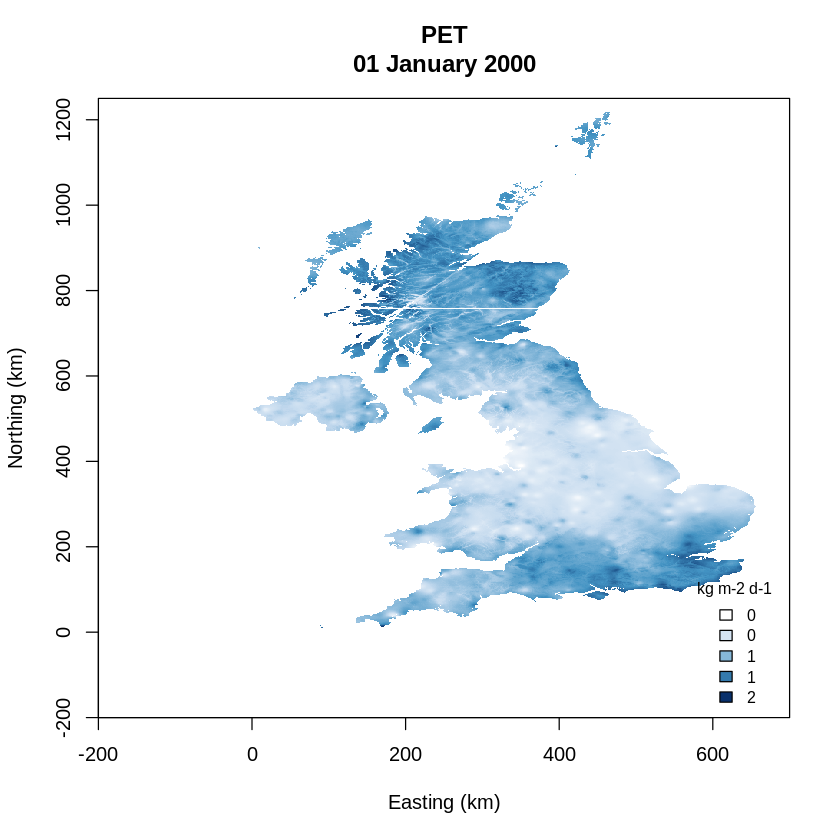

In [11]:
grid_plot <- grid

# Colour palette: white → blue
rain_cols <- colorRampPalette(c("white", "#c6dbef", "#4393c3", "#08306b"))(100)

image(
  x = x / 1000,     # convert metres to km for cleaner axis labels
  y = y / 1000,
  z = grid_plot,
  col  = rain_cols,
  xlab = "Easting (km)",
  ylab = "Northing (km)",
  main = paste0("PET", "\n", format(datetimes[t_index], "%d %B %Y"))
)

# Simple colourbar using legend
legend("bottomright",
  legend = round(seq(min(grid, na.rm=TRUE), max(grid, na.rm=TRUE), length.out = 5)),
  fill   = rain_cols[c(1, 25, 50, 75, 100)],
  title  = units, bty = "n", cex = 0.8
)

To plot this more nicely, several plotting libraries need to be installed, which can take upwards of 15 minutes. There are slight variations in how this needs to be done for different platforms. Follow the instructions and run the cells *only* for the platform you are currently running the notebook on.

#### Google Colab

In [12]:
# Set up r2u for installing terra (uses precompiled binaries to bypass gdal problems)
download.file(
  "https://github.com/eddelbuettel/r2u/raw/master/inst/scripts/add_cranapt_focal.sh",
  "add_cranapt_focal.sh"
)
Sys.chmod("add_cranapt_focal.sh", "0755")
system("./add_cranapt_focal.sh")

#### JASMIN Notebook Service

JASMIN sometimes fails to find the proj directory, which contains the files needed for spatial plotting, meaning you have to set it manually. If you have followed the instructions for the JASMIN Notebook Service on the README, the proj directory should be installed in the directory written out in the commands below. You will need to replace "USERNAME" with your JASMIN username (potentially different to your CEDA username used above) and "ENVNAME" with the name of the environment you created with conda when cloning the jasR environment (this is fdriR if you've followed the instructions word for word).

In [ ]:
# only needs to be run on the JASMIN Notebook Service.

proj_dir <- "/gws/ssde/j25b/fdri/envs/fdricombo/share/proj"
Sys.setenv(PROJ_DATA = file.path(proj_dir))
Sys.setenv(PROJ_LIB = file.path(proj_dir))

To check you have set this correctly, the following command should pass (i.e. not produce an error):

In [ ]:
stopifnot(file.exists(file.path(Sys.getenv("PROJ_DATA"), "proj.db")))

If it produces an error, it is likely proj_dir and thus PROJ_DATA is not correct. You can see what PROJ_DATA is with the below command. Double check proj_dir is set correctly.

In [ ]:
Sys.getenv("PROJ_DATA")

#### Binder

All packages are already set up and installed on Binder, no further configuration is required.

### All Platforms - Install Libraries

In [ ]:
pkgs <- c("rnaturalearth", "rnaturalearthdata")
new  <- pkgs[!pkgs %in% installed.packages()[, "Package"]]
if (length(new) > 0) install.packages(new, repos = "https://cloud.r-project.org", verbose = TRUE)

In [ ]:
library('ggplot2')
library('rnaturalearth')
library('rnaturalearthdata')

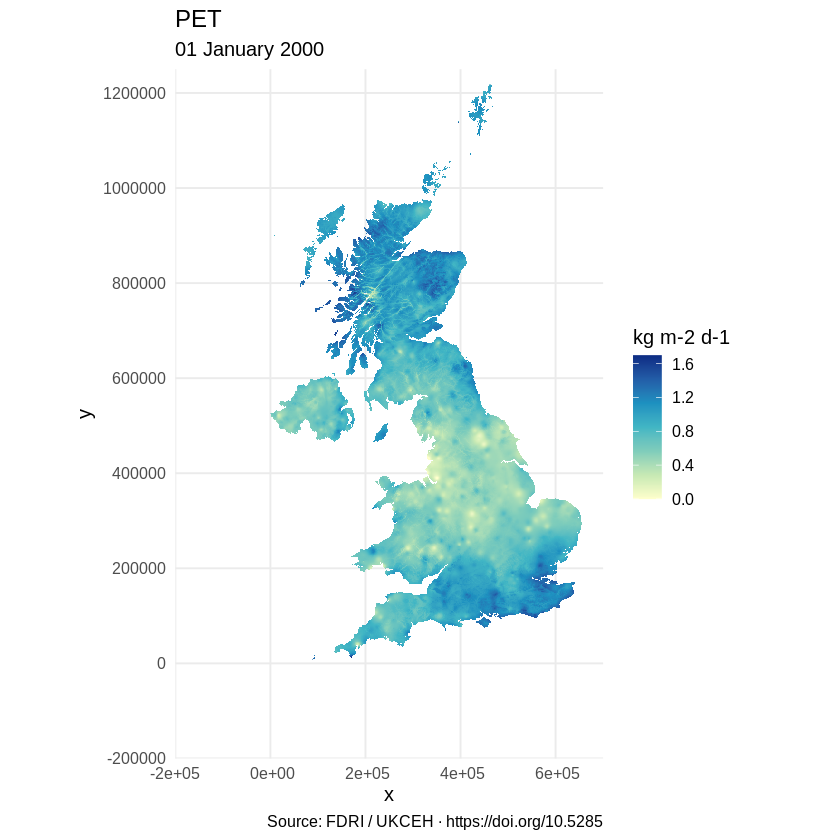

In [15]:
# ── Build long-format data frame for ggplot2 ──────────────────────────────────
map_df <- expand.grid(x = x, y = y)
map_df$value <- as.vector(grid)

# Get GB/Ireland coastline for overlay
gb <- ne_countries(country = c("United Kingdom", "Ireland"),
                   scale = "medium", returnclass = "sf")

# Clip to the dataset's geographic extent
x_range <- range(x)
y_range <- range(y)

p_map <- ggplot() +
  geom_raster(data = map_df, # specify the data to plot, and it's axes
              aes(x = x, y = y, fill = value), na.rm = TRUE) +
  scale_fill_distiller( # customise how the data is displayed
    palette   = "YlGnBu",
    direction = 1,
    name      = units,
    na.value  = NA,
    labels    = scales::comma
  ) +
  coord_sf( # coordinate display customisation
    expand = FALSE
  ) +
  labs( # label customisation
    title    = paste("PET"),
    subtitle = format(datetimes[t_index], "%d %B %Y"),
    x = "x", y = "y",
    caption  = "Source: FDRI / UKCEH · https://doi.org/10.5285"
  ) +
  theme_minimal(base_size = 12) # overall theme customisation


print(p_map)


---

**Data citation:** Hydro-PE, UKCEH, https://doi.org/10.5285/2aa2c8ab-9e32-4b3b-9636-503912305aca